In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import soundfile as sf
import torch
import torch.nn as nn



In [ ]:
df_meta = pd.read_csv("data/train.csv")

print(df_meta.head())

In [ ]:


input_path = 'data/train_audio/'

step = 10
samples = 500000
fft_array = np.empty((0, samples//2 + 1), dtype=float)
labels = np.empty(0, dtype=object)

# n_samples = 100
# df_sampled = df_meta.sample(n=n_samples, random_state=42)

# n samples per class in column "primary_label"
# n_per_class = 5

# df_balanced = (
#     df_meta.groupby("primary_label", group_keys=False)
#       .sample(n=n_per_class, random_state=42, replace=True)
#       .reset_index(drop=True)
# )

df_meta_subset = df_meta[df_meta['filename'].str.contains('greyel')]

for i, file in enumerate(df_meta_subset["filename"]):
    data, samplerate = sf.read(f'{input_path}{file}')

    resampled_data = sp.signal.resample(data, samples)
    fourier = np.fft.rfft(resampled_data)
    fft_array = np.vstack((fft_array, fourier))
    labels = np.append(labels, df_meta_subset[df_meta_subset["filename"] == file]['primary_label'].values[0])
    print(f"Processed {i} files")
    # # The maximum frequency is half the sample rate
    # points_per_freq = len(data) / (samplerate / 2)

    # nyquist_freq = samplerate / 2
    # print(f"Nyquist frequency: {nyquist_freq} Hz")

    # fft_bins = len(data)/2
    # resolution = nyquist_freq / fft_bins
    # print(f"FFT resolution: {resolution} Hz per bin")

    # for i in range(0, int(nyquist_freq), step):
    #     idx = int(points_per_freq * i)
np.save("fft_array_2.npy", fft_array)
np.save("labels_2.npy", labels)

size_mb = fft_array.nbytes / (1024 ** 2)
print(f"{size_mb:.2f} MB")




In [ ]:
print((fft_array.nbytes/(1024**3)/100)*40000)
labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(labels, counts):
    print(f"{label}: {count}")

In [87]:
data_1 = np.load("data/processed/fft_array.npy")
y_1 = np.load("data/processed/labels.npy", allow_pickle=True)

data_2 = np.load("data/processed/fft_array_2.npy")
y_2 = np.load("data/processed/labels_2.npy", allow_pickle=True)

data = np.vstack((data_1, data_2))
y = np.append(y_1, y_2)

In [88]:
abs_fft_array = np.abs(data).astype(np.float32, copy=False)
print(f'Size of abs_fft_array: {abs_fft_array.nbytes / (1024 ** 3):.2f} GB')

Size of abs_fft_array: 0.89 GB


In [134]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(abs_fft_array, y_encoded, test_size=0.2, random_state=42)

In [136]:
from sklearn.preprocessing import StandardScaler, normalize
# scaler = StandardScaler()
# scaled_fft_array = scaler.fit_transform(X_train)
# print(X_train[0:5, 0:5])
# X_train = scaled_fft_array
# print(X_train[0:5, 0:5])

normalized_fft_array = normalize(X_train, norm='l2')
print(X_train[0:5, 0:5])
X_train = normalized_fft_array
print(X_train[0:5, 0:5])




[[1.55440029e+04 1.24204434e+04 1.03028057e+04 1.21596670e+04
  2.56599980e+04]
 [5.27876019e-01 2.94686246e+00 2.86105895e+00 6.18025112e+00
  6.95776033e+00]
 [4.77639771e+00 5.06108189e+00 4.77344418e+00 4.84375381e+00
  6.50874424e+00]
 [7.43005753e-01 1.08234873e+01 1.09466200e+01 1.39632235e+01
  1.21160488e+01]
 [1.74544868e+01 5.55617714e+00 7.53498077e+00 1.42168226e+01
  1.23084345e+01]]
[[6.4761102e-02 5.1747393e-02 4.2924661e-02 5.0660919e-02 1.0690746e-01]
 [1.0472005e-04 5.8459857e-04 5.6757691e-04 1.2260382e-03 1.3802806e-03]
 [1.0284336e-03 1.0897306e-03 1.0277977e-03 1.0429365e-03 1.4014351e-03]
 [7.2271665e-05 1.0527933e-03 1.0647704e-03 1.3581933e-03 1.1785199e-03]
 [3.7302992e-03 1.1874427e-03 1.6103443e-03 3.0383593e-03 2.6305066e-03]]


In [ ]:

#this should really be done on the raw audio data, but for now we can try it on the FFT data
from scipy.signal import savgol_filter
window_length = 20
polyorder = 3
filtered = savgol_filter(X_train, window_length=window_length, polyorder=polyorder)
X_train = filtered

In [ ]:
# from scipy.signal import savgol_filter
# window_length = 20
# polyorder = 3
# example_fft = X_train[1, :]
# filtered1 = savgol_filter(example_fft, window_length=window_length, polyorder=polyorder)

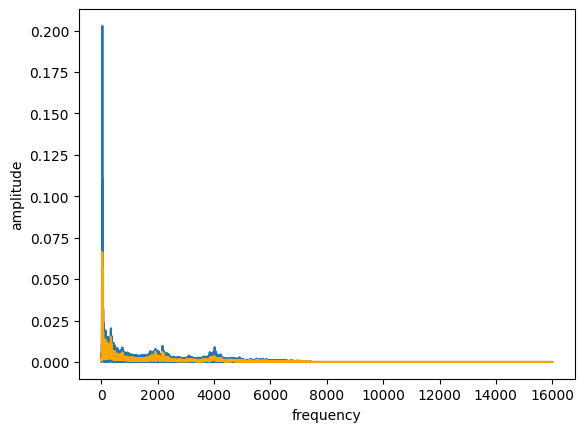

In [ ]:
# import matplotlib.pyplot as plt
# w = np.linspace(0, 16000, len(example_fft))
# #freqs = np.fft.rfftfreq(len(X_train[0,:]), d=1/32000)
# plt.plot(w, example_fft)
# plt.plot(w, filtered1, label='Smoothed', color='orange')    
# plt.xlabel('frequency')
# plt.ylabel('amplitude')
# plt.show()

In [138]:
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()


print(X_train.shape)
X_train = X_train.unsqueeze(1) # Add a channel dimension for CNN input
print(X_train.shape)

X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 20
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)


torch.Size([765, 250001])
torch.Size([765, 1, 250001])


In [139]:
model = nn.Sequential()
model.add_module('conv1', nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=1))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool1d(kernel_size=2, stride=2))
model.add_module('conv2', nn.Conv1d(in_channels=64, out_channels=1, kernel_size=5, stride=1, padding=1))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool1d(kernel_size=2, stride=2))
#model.add_module('flatten', nn.Flatten())
model.add_module('fc1', nn.Linear(62498, 640))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))
model.add_module('fc2', nn.Linear(640, len(label_encoder.classes_)))
model.to(device)
# conv = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=1)
# for x_batch, y_batch in train_dl:
#     test = conv(x_batch)
#     print(test.shape)


Sequential(
  (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 1, kernel_size=(5,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=62498, out_features=640, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=640, out_features=2, bias=True)
)

In [140]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        pred = pred.squeeze()  # Remove extra dimensions if necessary
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

Epoch 0  Accuracy 0.5137
Epoch 1  Accuracy 0.5176
Epoch 2  Accuracy 0.5176
Epoch 3  Accuracy 0.5176


KeyboardInterrupt: 

In [22]:
input_size = X_train.shape[1]
hidden_units = [input_size, input_size//2, input_size//4]

all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit, dtype=torch.float32)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(label_encoder.classes_), dtype=torch.float32))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

RuntimeError: [enforce fail at alloc_cpu.cpp:127] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 250002000004 bytes. Error code 12 (Cannot allocate memory)